# feature engineering - trying stuff out

Working out the actual formulas/bins before dropping them into **src/feature_engineering.py**. This is just the scratch version.

## **IMPORTANT: This notebook contains NO production code.**

## **This is purely an explanatory notebook used to walk through and visualize the process**
## **All real code, logic, and files live in [`src/`](../src/) — this notebook is not run as part of the pipeline**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

df = pd.read_csv('../data/processed/cleaned.csv')  # already cleaned, targets encoded
df.shape

(30000, 18)

In [2]:
df.head()

,Class of Travel,Quota,Source Station,Destination Station,Number of Passengers,Age of Passengers,Travel Distance,Number of Stations,Travel Time,Train Type,Seat Availability,Special Considerations,Holiday or Peak Season,Waitlist Position,Confirmation Status,journey_month,journey_dayofweek,days_before_journey
0,3AC,General,NDLS,CSMT,4,Child,1656,17,37,Shatabdi,159,Senior Citizen,Yes,0.0,1,9,6,244
1,3AC,Premium Tatkal,MMCT,LTT,5,Senior Citizen,1932,18,6,Shatabdi,309,No_Special_Consideration,Yes,97.0,0,9,0,244
2,3AC,Ladies,GKP,BBS,5,Adult,155,4,17,Express,143,No_Special_Consideration,Yes,0.0,1,9,1,244
3,3AC,Ladies,ASR,KOAA,1,Senior Citizen,1840,5,16,Superfast,256,Senior Citizen,No,11.0,0,9,2,244
4,2AC,Tatkal,MAS,SBC,3,Child,1766,9,32,Express,58,No_Special_Consideration,Yes,0.0,1,9,3,244


## seat_pressure

passengers / (seat availability + 1). the +1 avoids div-by-zero when seats == 0. (checked in EDA, no negative seat availability values, so the +1 is purely a div-by-zero guard, nothing messier.)

In [3]:
df['seat_pressure'] = df['Number of Passengers'] / (df['Seat Availability'] + 1)
df['seat_pressure'].describe()

count    30000.000000
mean         0.040332
std          0.182938
min          0.002000
25%          0.006920
50%          0.012048
75%          0.024096
max          5.000000
Name: seat_pressure, dtype: float64

<Axes: xlabel='seat_pressure', ylabel='Count'>

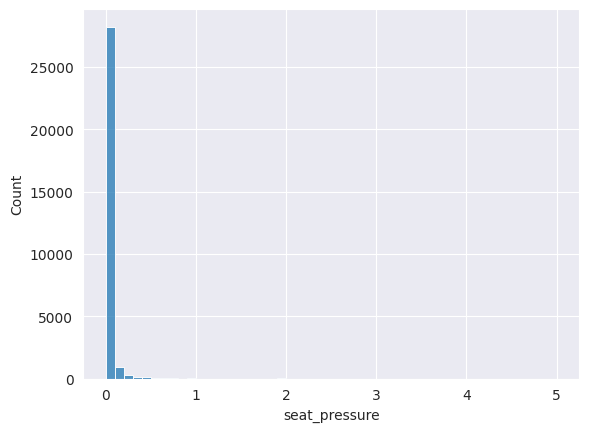

In [4]:
sns.histplot(df['seat_pressure'], bins=50)

right-skewed as expected, most bookings have low pressure, long tail of high-pressure ones.

(0.0, 1.0)

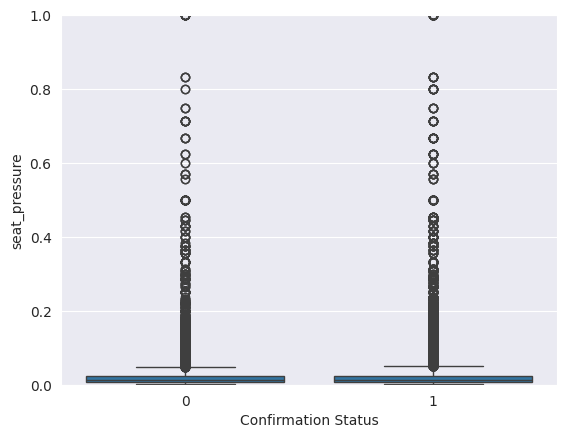

In [5]:
sns.boxplot(x='Confirmation Status', y='seat_pressure', data=df)
plt.ylim(0, 1)

In [6]:
df.groupby('Confirmation Status')['seat_pressure'].describe()

,count,mean,std,min,25%,50%,75%,max
Confirmation Status,,,,,,,,
0,10053.0,0.038922,0.174856,0.002,0.006803,0.011976,0.023364,5.0
1,19947.0,0.041042,0.186879,0.002,0.006961,0.012107,0.024390,5.0


yeah, this confirms what I already saw in EDA — means are 0.079 vs 0.078, basically no separation. keeping the feature anyway since it's the most logically-grounded one I have, but not expecting it to carry the model on its own.

## route_length_per_stop

In [7]:
df['route_length_per_stop'] = df['Travel Distance'] / (df['Number of Stations'] + 1)
df['route_length_per_stop'].describe()

count    30000.000000
mean       119.667264
std        110.300623
min          2.500000
25%         47.039474
50%         88.948684
75%        150.878472
max        666.333333
Name: route_length_per_stop, dtype: float64

<Axes: xlabel='route_length_per_stop', ylabel='Count'>

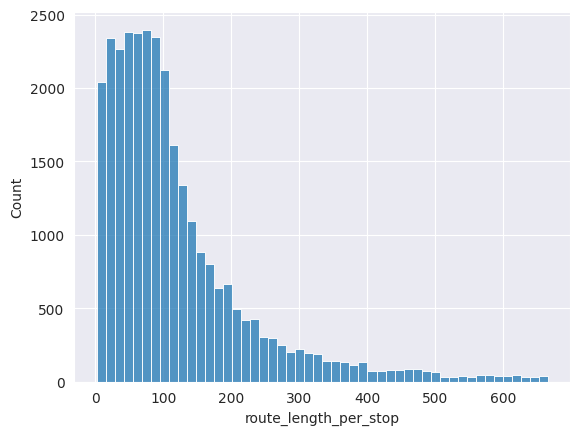

In [8]:
sns.histplot(df['route_length_per_stop'], bins=50)

In [9]:
df.groupby('Confirmation Status')['route_length_per_stop'].mean()

Confirmation Status
0    119.962135
1    119.518653
Name: route_length_per_stop, dtype: float64

no real separation here either. logically it shouldn't be related to confirmation status anyway (it's about route geography, not booking pressure) — including it mainly for Stage 2 in case route length correlates with waitlist severity rather than confirmation itself.

## booking_urgency_bucket — this one changed after EDA

found something important in the EDA notebook: **days_before_journey** is **constant at 244 for every row** in this dataset (Date of Journey is always Booking Date + 244 days). Checking that here before building bins on top of a broken assumption.

In [10]:
df['days_before_journey'].describe()

count    30000.0
mean       244.0
std          0.0
min        244.0
25%        244.0
50%        244.0
75%        244.0
max        244.0
Name: days_before_journey, dtype: float64

confirmed, std is 0. so any binning I do here is going to put every row in the same bucket — there's no actual 'last minute vs planned early' variation to capture in this dataset. going through the motions below anyway since this is what **feature_engineering.py** needs to match, but the output confirms it's dead weight.

In [11]:
df['booking_urgency_bucket'] = pd.cut(
    df['days_before_journey'],
    bins=[-1, 2, 14, 59, np.inf],
    labels=['last_minute', 'short', 'planned', 'early']
)
df['booking_urgency_bucket'].value_counts()

booking_urgency_bucket
early          30000
last_minute        0
short              0
planned            0
Name: count, dtype: int64

yep — 100% of rows land in **early**. this column is a constant, same problem as its source. it'll get one-hot-encoded into a single always-1 column that contributes nothing to either model. not fixing the bins (there's nothing to fix, the underlying data has no variance) — just documenting that this feature is currently dead and shouldn't be expected to help. if I get real transactional data later with actual booking-lead-time variation, the bin logic itself is still fine, it's the source data that's flat here.

## is_peak_or_holiday

In [12]:
df['is_peak_or_holiday'] = (df['Holiday or Peak Season'] == 'Yes').astype(int)
df['is_peak_or_holiday'].value_counts()

is_peak_or_holiday
1    15089
0    14911
Name: count, dtype: int64

In [13]:
pd.crosstab(df['is_peak_or_holiday'], df['Confirmation Status'], normalize='index')

Confirmation Status,0,1
is_peak_or_holiday,,
0,0.331768,0.668232
1,0.338392,0.661608


~66.7% confirmed regardless of peak/holiday flag — basically no difference between the two groups. another one that's not pulling much weight, but cheap to keep.

## sanity check before moving into src/

In [14]:
new_cols = ['is_peak_or_holiday', 'seat_pressure', 'route_length_per_stop', 'booking_urgency_bucket']
df[new_cols].isnull().sum()

is_peak_or_holiday        0
seat_pressure             0
route_length_per_stop     0
booking_urgency_bucket    0
dtype: int64

In [15]:
numeric_new = ['seat_pressure', 'route_length_per_stop']
np.isinf(df[numeric_new]).sum()

seat_pressure            0
route_length_per_stop    0
dtype: int64

no nulls, no infs — passes the same checks **feature_engineering.py's** **sanity_check()** runs. structurally fine, just not carrying much signal.

## correlation between the new numeric features and each other

<Axes: >

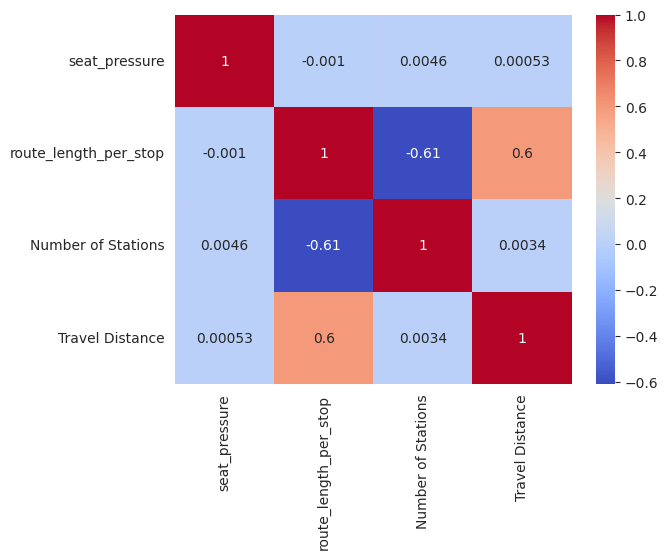

In [16]:
corr_cols = ['seat_pressure', 'route_length_per_stop', 'Number of Stations', 'Travel Distance']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')

nothing badly correlated, no redundancy concerns. (dropped **days_before_journey** out of this correlation check since it's constant — correlation with a constant is undefined/NaN anyway.)

## honest summary before writing this into the pipeline

Out of the four engineered features:
- **seat_pressure**: weak but non-zero separation, keeping it, logically the strongest candidate
- **route_length_per_stop**: no separation with Confirmation Status seen here, kept mainly on the chance it helps Stage 2 (waitlist severity), untested
- **booking_urgency_bucket**: **confirmed dead** — built on a constant source column in this dataset
- **is_peak_or_holiday**: negligible separation, cheap to keep, not expecting much from it

This lines up with the actual Stage 1 metrics later coming back close to chance (ROC-AUC ~0.51) — it's not a training/tuning problem, the feature set itself doesn't carry much signal for **Confirmation Status** in this particular dataset. Next real improvement would be getting **days_before_journey** to actually vary (if this is regenerated) or engineering something off **Class of Travel** / **Quota** / route pair, none of which are touched yet.